Python 3.12.9

**Файлы для соревнования**
* hotels_train.csv - набор данных для обучения
* hotels_test.csv - набор данных для оценки качества
* submission.csv - файл сабмишна в нужном формате

**Признаки**
* *hotel_address* - адрес отеля
* *review_date* - дата, когда рецензент разместил соответствующий отзыв.
* *average_score* - средний балл отеля, рассчитанный на основе последнего комментария за последний год
* *hotel_name* - название отеля
* *reviewer_nationality* - национальность рецензента
* *negative_review* - отрицательный отзыв, который рецензент дал отелю.
* *review_total_negative_word_counts* - общее количество слов в отрицательном отзыв
* *positive_review* - положительный отзыв, который рецензент дал отелю
* *review_total_positive_word_counts* - общее количество слов в положительном отзыве
* *reviewer_score* - оценка, которую рецензент поставил отелю на основе своего опыта
* *total_number_of_reviews_reviewer_has_given* - количество отзывов, которые рецензенты дали в прошлом
* *total_number_of_reviews* - общее количество действительных отзывов об отеле
* *tags* - теги, которые рецензент дал отелю.
* *days_since_review* - продолжительность между датой проверки и датой очистки
* *additional_number_of_scoring* - есть также некоторые гости, которые просто поставили оценку сервису, а не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
* *lat* - широта отеля
* *lng* - долгота отеля

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from scipy import stats

import seaborn as sns
from matplotlib import pyplot as plt
import plotly

# **Подготовка данных**

In [2]:
# train
data_hotels = pd.read_csv('D:/Skillfactory/data/hotels_train.csv')
hotels = data_hotels.copy()

In [3]:
# test
hotels_test = pd.read_csv('D:/Skillfactory/data/hotels_test.csv')

### **1. Общая информация**

In [4]:
hotels.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097


In [5]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [6]:
hotels.describe()

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,lat,lng
count,386803.000000,386803.000000,386803.000000,386803.000000,386803.000000,386803.00000,386803.000000,384355.000000,384355.000000
mean,498.246536,8.397231,18.538988,2743.992042,17.776985,7.17725,8.396906,49.443522,2.823402
std,500.258012,0.547881,29.703369,2316.457018,21.726141,11.05442,1.636090,3.466936,4.579043
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.00000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.00000,7.500000,48.214662,-0.143649
50%,342.000000,8.400000,9.000000,2134.000000,11.000000,3.00000,8.800000,51.499981,-0.000250
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.00000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.00000,10.000000,52.400181,16.429233


In [7]:
hotels.isna().shape[0]

386803

### **2.1 Поиск дубликатов и выбросов**

Дубликаты

In [8]:
test_dupl = list(hotels.columns)
mask = hotels.duplicated(subset = test_dupl)
test_duplicates = hotels[mask]
print(f'Число найденных дубликатов: {test_duplicates.shape[0]}') 

Число найденных дубликатов: 307


In [9]:
hotels = hotels.drop_duplicates(subset=test_dupl)

Выберем несколько *числовых* признаков, по которым могут быть выбросы и визуализируем их

In [10]:
numeric_columns = hotels.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовые столбцы для анализа выбросов: {numeric_columns}")

Числовые столбцы для анализа выбросов: ['additional_number_of_scoring', 'average_score', 'review_total_negative_word_counts', 'total_number_of_reviews', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'reviewer_score', 'lat', 'lng']


Не обрабатываем reviewer score т.к. это target

In [11]:
outliers = ['additional_number_of_scoring', 'average_score', 'review_total_negative_word_counts', 'total_number_of_reviews', 
            'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'lat', 'lng']

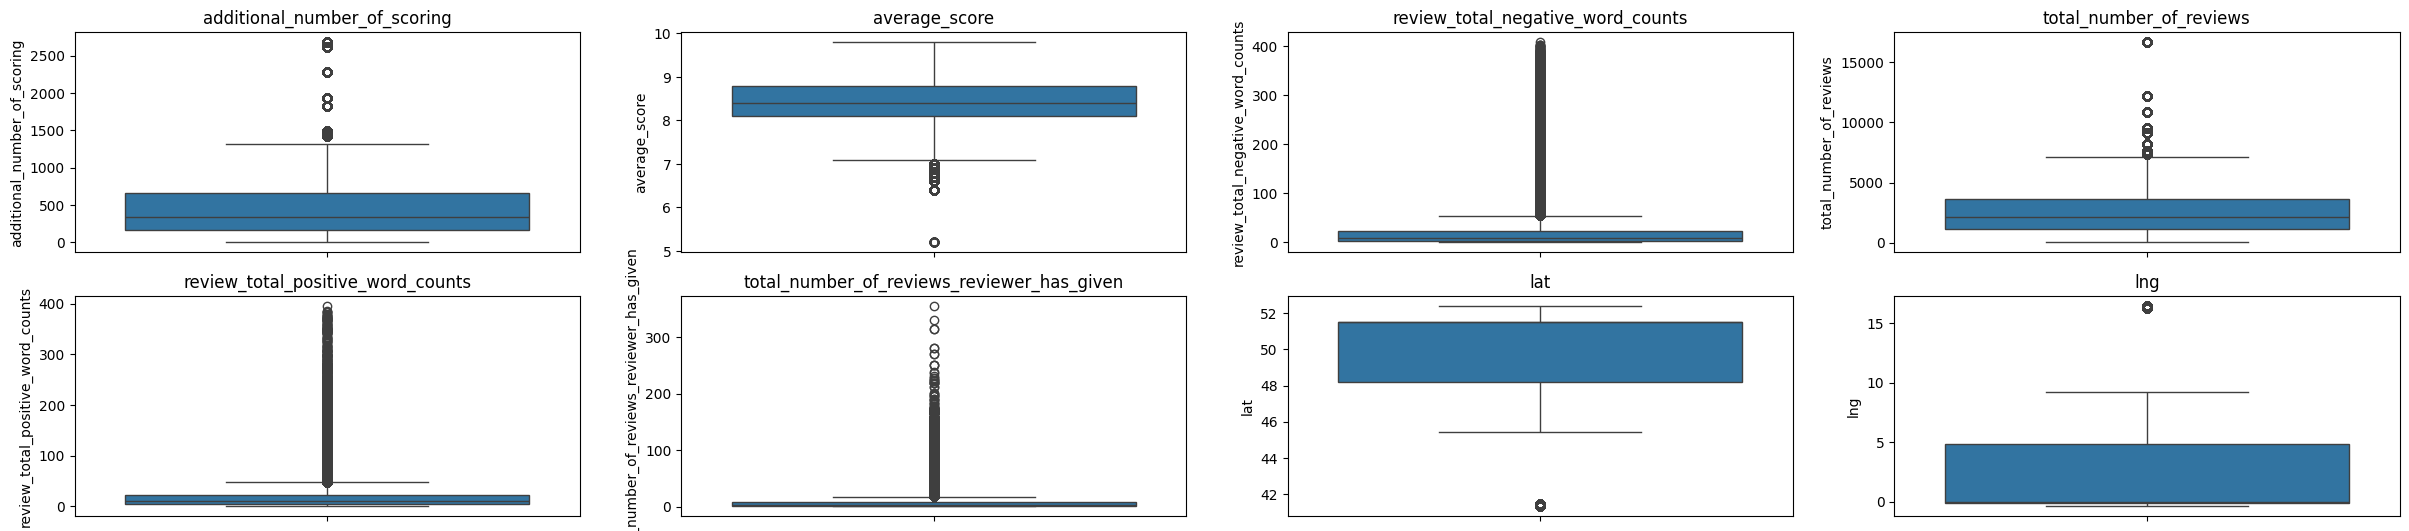

In [12]:
plt.figure(figsize=(30, 20))
for i, col in enumerate(outliers, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(y = hotels[col])
    plt.title(col)
plt.show()

У нас всего 386 803 строк. Мы обнаружили **27 187 выбросов** - это довольно много. Уберём хвосты у некоторых признаков

In [13]:
upper_bounds = {}

for col in outliers:
    Q1 = hotels[col].quantile(0.25)
    Q3 = hotels[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3+1.5*IQR
    upper_bounds[col] = upper
    hotels[f'{col}_clean'] = hotels[col].clip(upper=upper)

In [14]:
hotels['additional_number_of_scoring_log'] = np.log1p(hotels['additional_number_of_scoring'])

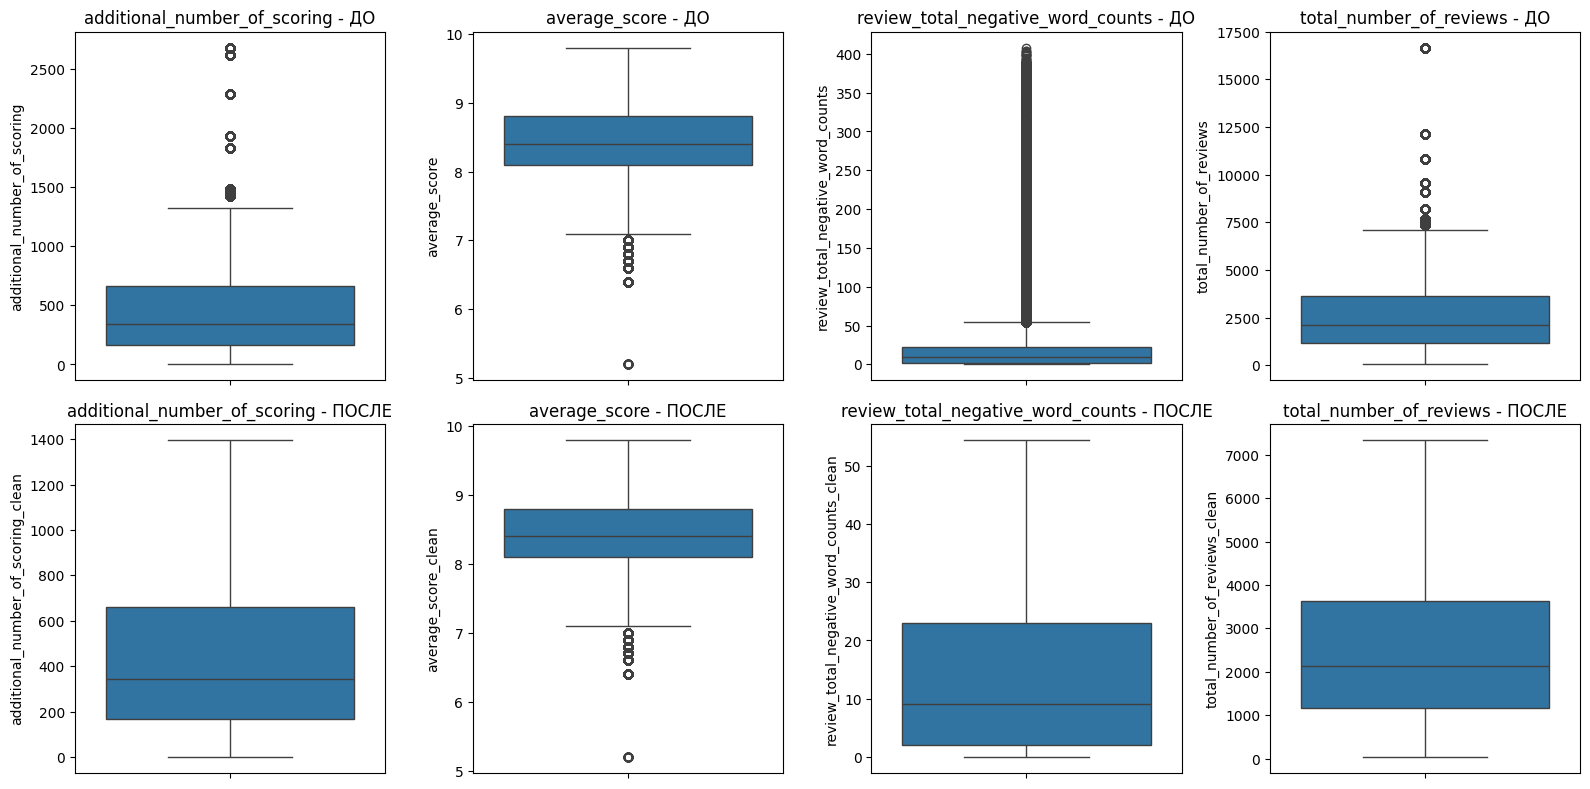

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

outliers_4 = ['additional_number_of_scoring', 'average_score', 
              'review_total_negative_word_counts', 'total_number_of_reviews']

for i, col in enumerate(outliers_4):
    # До обработки
    sns.boxplot(y=hotels[col], ax=axes[0, i])
    axes[0, i].set_title(f'{col} - ДО')
    
    # После обработки  
    sns.boxplot(y=hotels[f'{col}_clean'], ax=axes[1, i])
    axes[1, i].set_title(f'{col} - ПОСЛЕ')

plt.tight_layout()
plt.show()

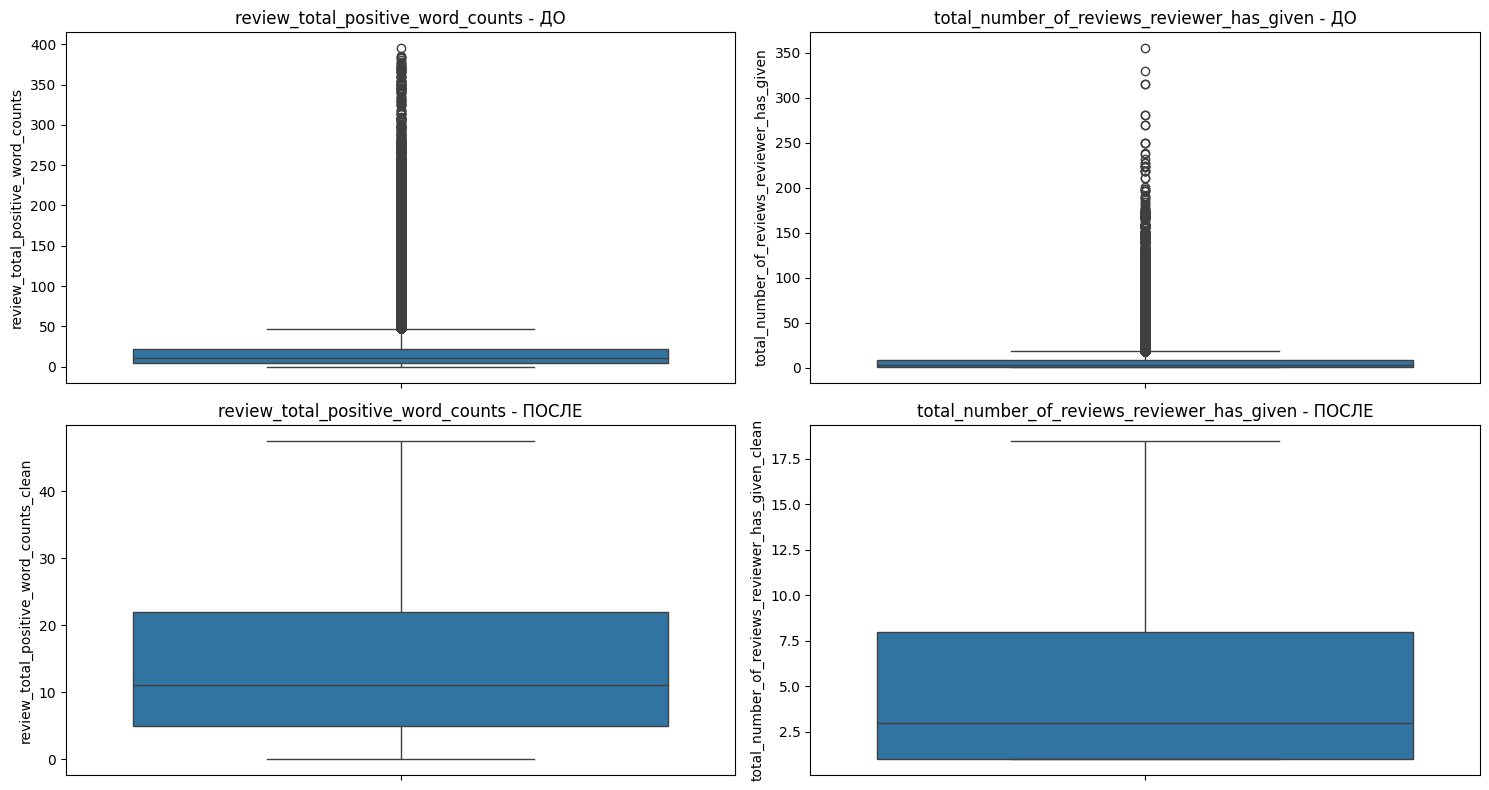

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

outliers_2 = ['review_total_positive_word_counts', 
             'total_number_of_reviews_reviewer_has_given']

for i, col in enumerate(outliers_2):
    # До обработки
    sns.boxplot(y=hotels[col], ax=axes[0, i])
    axes[0, i].set_title(f'{col} - ДО')
    
    # После обработки  
    sns.boxplot(y=hotels[f'{col}_clean'], ax=axes[1, i])
    axes[1, i].set_title(f'{col} - ПОСЛЕ')

plt.tight_layout()
plt.show()

In [17]:
columns_to_drop = [
    'additional_number_of_scoring',
    'average_score',
    'review_total_negative_word_counts',
    'total_number_of_reviews',
    'review_total_positive_word_counts',
    'total_number_of_reviews_reviewer_has_given'
]

In [18]:
hotels = hotels.drop(columns=columns_to_drop)

In [19]:
print("Оставшиеся столбцы:")
print(list(hotels.columns))

Оставшиеся столбцы:
['hotel_address', 'review_date', 'hotel_name', 'reviewer_nationality', 'negative_review', 'positive_review', 'reviewer_score', 'tags', 'days_since_review', 'lat', 'lng', 'additional_number_of_scoring_clean', 'average_score_clean', 'review_total_negative_word_counts_clean', 'total_number_of_reviews_clean', 'review_total_positive_word_counts_clean', 'total_number_of_reviews_reviewer_has_given_clean', 'lat_clean', 'lng_clean', 'additional_number_of_scoring_log']


In [20]:
hotels.head(2)

,hotel_address,review_date,hotel_name,reviewer_nationality,negative_review,positive_review,reviewer_score,tags,days_since_review,lat,lng,additional_number_of_scoring_clean,average_score_clean,review_total_negative_word_counts_clean,total_number_of_reviews_clean,review_total_positive_word_counts_clean,total_number_of_reviews_reviewer_has_given_clean,lat_clean,lng_clean,additional_number_of_scoring_log
0,Stratton Street Mayfair Westminster Borough Lo...,2/19/2016,The May Fair Hotel,United Kingdom,Leaving,Staff were amazing,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671,581.0,8.4,3.0,1994,4.0,7.0,51.507894,-0.143671,6.366470
1,130 134 Southampton Row Camden London WC1B 5AF...,1/12/2017,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,location,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097,299.0,8.3,3.0,1361,2.0,14.0,51.521009,-0.123097,5.703782


### **2.2 Поиск пропусков**

Поищем пропуски в данном датасете.  
Вычислим средний по столбцам результат метода isnull() и получим долю пропусков в каждом столбце. Также, найдём столбцы, где доля пропусков больше 0.

In [21]:
hotels_null = hotels.isnull().mean() * 100
cols_with_null = hotels_null[hotels_null > 0].sort_values(ascending=False)
display(cols_with_null)

lat          0.633383
lng          0.633383
lat_clean    0.633383
lng_clean    0.633383
dtype: float64

Размер пропусков мал, но может влиять на метрику. Поэтому попробуем удалить только проблемные строки которые не будут существенно искажать результат, т.к. потеря данных минимальна

In [22]:
print(f"Размер до удаления: {hotels.shape}")
hotels_clean = hotels.dropna(subset=['lat', 'lng'])

print(f"Размер после удаления: {hotels_clean.shape}")
print(f"Удалено строк: {len(hotels) - len(hotels_clean)}")

Размер до удаления: (386496, 20)
Размер после удаления: (384048, 20)
Удалено строк: 2448


2 448 строк - не так уж много

### **2.3. Неинформативные признаки**

In [23]:
low_information_cols = [] 

for col in hotels_clean.columns:
    # наибольшая относительная частота в признаке
    top_freq = hotels_clean[col].value_counts(normalize=True).max()
    # доля уникальных значений от размера признака
    nunique_ratio = hotels_clean[col].nunique() / hotels_clean[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')

Похоже, что информативных признаков у нас нет.

### **2.4 Обработка object признаков**

In [24]:
cols_type = hotels_clean.select_dtypes(include=['object']).columns.tolist()
cols_type

['hotel_address',
 'review_date',
 'hotel_name',
 'reviewer_nationality',
 'negative_review',
 'positive_review',
 'tags',
 'days_since_review']

In [25]:
object_cols = ['hotel_address',
 'review_date',
 'hotel_name',
 'reviewer_nationality',
 'negative_review',
 'positive_review',
 'tags',
 'days_since_review']
display(hotels_clean.loc[:, object_cols].head())

,hotel_address,review_date,hotel_name,reviewer_nationality,negative_review,positive_review,tags,days_since_review
0,Stratton Street Mayfair Westminster Borough Lo...,2/19/2016,The May Fair Hotel,United Kingdom,Leaving,Staff were amazing,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day
1,130 134 Southampton Row Camden London WC1B 5AF...,1/12/2017,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,location,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day
2,151 bis Rue de Rennes 6th arr 75006 Paris France,10/18/2016,Legend Saint Germain by Elegancia,China,No kettle in room,No Positive,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,9/22/2015,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,Friendly staff quiet comfortable room spotles...,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day
4,Molenwerf 1 1014 AG Amsterdam Netherlands,3/5/2016,Golden Tulip Amsterdam West,Poland,Torn sheets,The staff was very friendly and helpful Break...,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day


Видим, что у нас есть 8 столбцов типа object. Некоторые из них можно преобразовать.  

У нас есть большое количество стран, выделим из них 20-30 популярных.  
Преобразовываем столбец 'review_date' в datetime.  
Адрес, название отеля - абсолютно ненужные признаки.  
Из негативных/позитивных отзывов вычленять что-то ручным методом - незачем. Но можно вытащить что-то определённое  
Тэги также не нужны.  
Дни с момента публикации отзыва - в принципе можно преобразовать в int.

**Числовые преобразования мы сделаем позже, в п. 3. Создание признаков**

### **3. Создание признаков**

#### reviewer_nationality

In [26]:
# Какие самые популярные страны есть

top_nationalities = hotels_clean['reviewer_nationality'].value_counts().head(30)
top_nationalities

reviewer_nationality
United Kingdom               183339
United States of America      26317
Australia                     16123
Ireland                       11059
United Arab Emirates           7570
Saudi Arabia                   6685
Netherlands                    6552
Switzerland                    6442
Canada                         5915
Germany                        5880
France                         5476
Israel                         4857
Italy                          4523
Belgium                        4492
Turkey                         4061
Kuwait                         3685
Spain                          3496
Romania                        3325
Russia                         2905
South Africa                   2869
China                          2543
Sweden                         2539
India                          2528
Greece                         2493
New Zealand                    2430
Singapore                      2298
Hong Kong                      2247
Poland 

In [27]:
top_countries = hotels_clean['reviewer_nationality'].value_counts().head(30).index
hotels_clean['reviewer_nationality'] = hotels_clean['reviewer_nationality'].apply(
    lambda x: x if x in top_countries else 'Other'
)

C:\Users\akres\AppData\Local\Temp\ipykernel_8464\2260125542.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotels_clean['reviewer_nationality'] = hotels_clean['reviewer_nationality'].apply(


In [28]:
onehot = pd.get_dummies(hotels_clean['reviewer_nationality'], prefix='nat').astype(int)
hotels_clean = pd.concat([hotels_clean.drop('reviewer_nationality', axis=1), onehot], axis=1)

display(hotels_clean.head(3))

,hotel_address,review_date,hotel_name,negative_review,positive_review,reviewer_score,tags,days_since_review,lat,lng,...,nat_ Singapore,nat_ South Africa,nat_ Spain,nat_ Sweden,nat_ Switzerland,nat_ Turkey,nat_ United Arab Emirates,nat_ United Kingdom,nat_ United States of America,nat_Other
0,Stratton Street Mayfair Westminster Borough Lo...,2/19/2016,The May Fair Hotel,Leaving,Staff were amazing,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671,...,0,0,0,0,0,0,0,1,0,0
1,130 134 Southampton Row Camden London WC1B 5AF...,1/12/2017,Mercure London Bloomsbury Hotel,poor breakfast,location,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097,...,0,0,0,0,0,0,0,1,0,0
2,151 bis Rue de Rennes 6th arr 75006 Paris France,10/18/2016,Legend Saint Germain by Elegancia,No kettle in room,No Positive,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643,...,0,0,0,0,0,0,0,0,0,0


#### review_date

In [29]:
hotels_clean['review_date'] = pd.to_datetime(hotels_clean['review_date'], format='%m/%d/%Y')

In [30]:
# Подумалось, что лучше поделить на год/месяц/день полностью отдельными столбцами
hotels_clean['review_year'] = hotels_clean['review_date'].dt.year
hotels_clean['review_month'] = hotels_clean['review_date'].dt.month
hotels_clean['review_dayofweek'] = hotels_clean['review_date'].dt.dayofweek

#### days_since_review

In [31]:
hotels_clean['days_since_review'] = hotels_clean['days_since_review'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\akres\AppData\Local\Temp\ipykernel_8464\2319716196.py:1: SyntaxWarning: invalid escape sequence '\d'
  hotels_clean['days_since_review'] = hotels_clean['days_since_review'].str.extract('(\d+)').astype(int)


In [32]:
object_cols_to_drop = ['hotel_address', 'hotel_name', 'negative_review', 
                       'positive_review', 'tags', 'review_date']
hotels_clean.drop(object_cols_to_drop, axis = 1, inplace=True)

In [33]:
hotels_clean.head(10)

,reviewer_score,days_since_review,lat,lng,additional_number_of_scoring_clean,average_score_clean,review_total_negative_word_counts_clean,total_number_of_reviews_clean,review_total_positive_word_counts_clean,total_number_of_reviews_reviewer_has_given_clean,...,nat_ Sweden,nat_ Switzerland,nat_ Turkey,nat_ United Arab Emirates,nat_ United Kingdom,nat_ United States of America,nat_Other,review_year,review_month,review_dayofweek
0,10.0,531,51.507894,-0.143671,581.0,8.4,3.0,1994,4.0,7.0,...,0,0,0,0,1,0,0,2016,2,4
1,6.3,203,51.521009,-0.123097,299.0,8.3,3.0,1361,2.0,14.0,...,0,0,0,0,1,0,0,2017,1,3
2,7.5,289,48.845377,2.325643,32.0,8.9,6.0,406,0.0,14.0,...,0,0,0,0,0,0,0,2016,10,1
3,10.0,681,48.888697,2.394540,34.0,7.5,0.0,607,11.0,8.0,...,0,0,0,0,1,0,0,2015,9,1
4,9.6,516,52.385601,4.847060,914.0,8.5,4.0,7341,20.0,10.0,...,0,0,0,0,0,0,0,2016,3,5
5,10.0,582,45.448188,9.257046,105.0,8.0,2.0,1607,16.0,1.0,...,0,0,0,0,0,0,0,2015,12,2
6,9.6,77,51.494231,-0.185114,854.0,7.8,6.0,3867,29.0,4.0,...,0,0,0,0,1,0,0,2017,5,3
7,8.3,192,48.208563,16.354169,227.0,8.3,40.0,2526,47.5,18.5,...,0,0,0,0,1,0,0,2017,1,0
8,8.3,618,51.500198,-0.179536,227.0,8.6,30.0,968,7.0,3.0,...,0,0,0,0,1,0,0,2015,11,1
9,6.7,548,51.505108,-0.213266,843.0,7.8,47.0,3801,0.0,1.0,...,0,0,0,0,1,0,0,2016,2,1


### **4. Распределения, корреляции**

Рассмотрим два признака – 'additional_number_of_scoring' (гости, которые просто поставили оценку сервису, а не оставили отзыв) и 'average_score' (средний балл отеля, рассчитанный на основе последнего комментария за последний год)

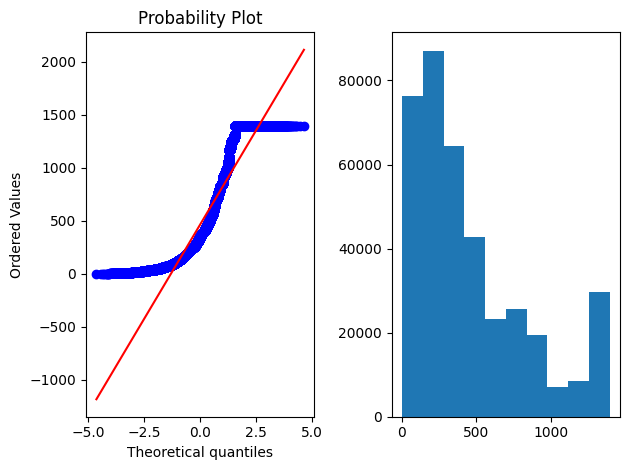

In [34]:
plt.subplot(1, 2, 1) 
stats.probplot(hotels_clean['additional_number_of_scoring_clean'], plot=plt) 

plt.subplot(1, 2, 2) # второй рисунок рядом
plt.hist(hotels_clean['additional_number_of_scoring_clean']) # гистограмма распределения

plt.tight_layout()
plt.show()

К-к график показал, что точки не располагаются на диагонали. Распределение рейтинга не является нормальным.

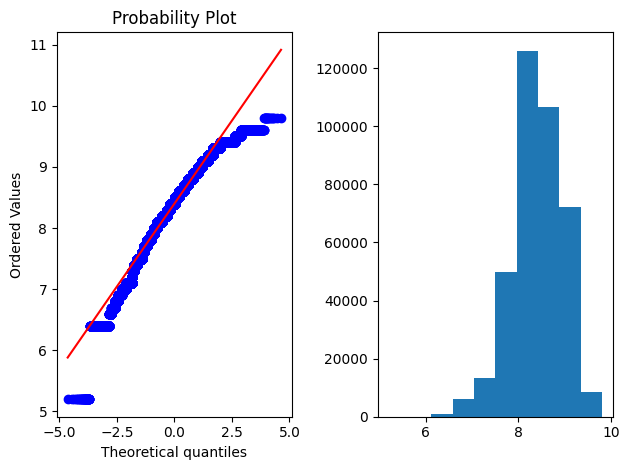

In [35]:
plt.subplot(1, 2, 1) 
stats.probplot(hotels_clean['average_score_clean'], plot=plt) 

plt.subplot(1, 2, 2) # второй рисунок рядом
plt.hist(hotels_clean['average_score_clean']) # гистограмма распределения

plt.tight_layout()
plt.show()

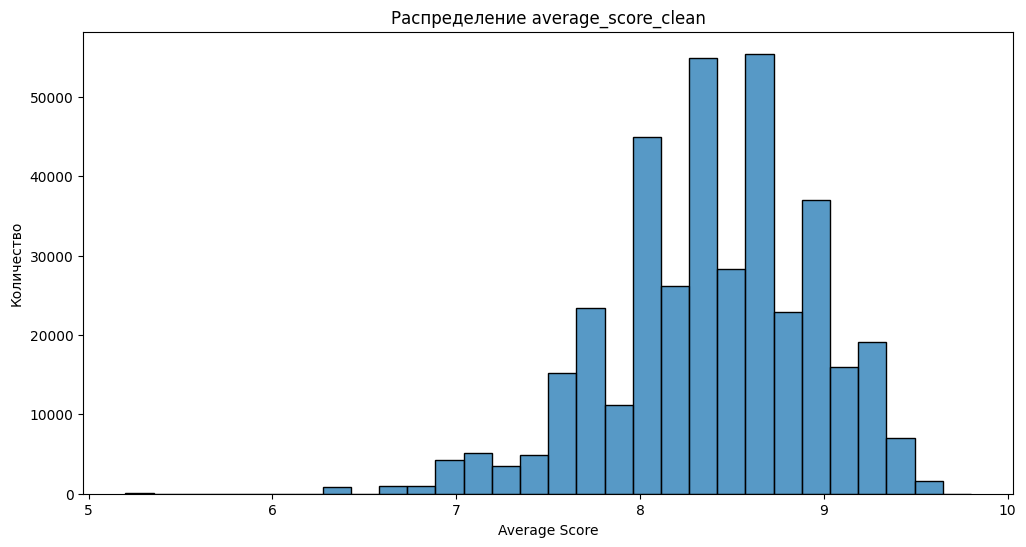

In [36]:
plt.figure(figsize=(12, 6))
sns.histplot(data=hotels_clean, x='average_score_clean', bins=30)
plt.title('Распределение average_score_clean')
plt.xlabel('Average Score')
plt.ylabel('Количество')
plt.show()

В случае среднего балла отеля на основе комментариев за последний год к-к график выглядит практически хорошо, в среднем многие точки располагаются на диагонали. Распределение среднего балла выглядит также практически нормальным

In [37]:
hotels_clean.to_csv('D:/Skillfactory/data/Booking reviews (PJ-03)/hotels_clean.csv', index=False)

*Окончательный вариант файла*

### **5. Обучение модели**

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

In [39]:
# Очищенный train
hotels_train = pd.read_csv('D:/Skillfactory/data/Booking reviews (PJ-03)/hotels_clean.csv')

In [40]:
hotels_train.head(1)

,reviewer_score,days_since_review,lat,lng,additional_number_of_scoring_clean,average_score_clean,review_total_negative_word_counts_clean,total_number_of_reviews_clean,review_total_positive_word_counts_clean,total_number_of_reviews_reviewer_has_given_clean,...,nat_ Sweden,nat_ Switzerland,nat_ Turkey,nat_ United Arab Emirates,nat_ United Kingdom,nat_ United States of America,nat_Other,review_year,review_month,review_dayofweek
0,10.0,531,51.507894,-0.143671,581.0,8.4,3.0,1994,4.0,7.0,...,0,0,0,0,1,0,0,2016,2,4


In [41]:
# test
hotels_test = pd.read_csv('D:/Skillfactory/data/hotels_test.csv')

hotels_test.head(1)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102


In [42]:
print(f"Train size: {hotels_train.shape}")
print(f"Test size: {hotels_test.shape}")

Train size: (384048, 47)
Test size: (128935, 16)


In [43]:
print(hotels_train['days_since_review'].head())

0    531
1    203
2    289
3    681
4    516
Name: days_since_review, dtype: int64


In [44]:
print(hotels_train['days_since_review'].head())

0    531
1    203
2    289
3    681
4    516
Name: days_since_review, dtype: int64


Функция feature engineering для train и test.  
df - входной дф без имени

In [45]:
def preprocess_hotels(
    hotels_df,
    upper_bounds=None,
    top_countries=None,
    is_train=True
):
    hotels_df = hotels_df.copy()

    print("\n==== preprocess_hotels ====")
    print("is_train:", is_train)
    print("columns:", list(hotels_df.columns))
    print("===========================\n")

    # ================= days_since_review =================
    if 'days_since_review' in hotels_df.columns:
        if hotels_df['days_since_review'].dtype == object:
            hotels_df['days_since_review'] = (
                hotels_df['days_since_review']
                .str.extract(r'(\d+)')
                .astype(float)
            )

    # ================= review_date =================
    if 'review_date' in hotels_df.columns:
        hotels_df['review_date'] = pd.to_datetime(
            hotels_df['review_date'],
            errors='coerce'
        )
        hotels_df['review_year'] = hotels_df['review_date'].dt.year
        hotels_df['review_month'] = hotels_df['review_date'].dt.month
        hotels_df['review_dayofweek'] = hotels_df['review_date'].dt.dayofweek

    # ================= выбросы =================
    numeric_cols = [
        'additional_number_of_scoring',
        'average_score',
        'review_total_negative_word_counts',
        'total_number_of_reviews',
        'review_total_positive_word_counts',
        'total_number_of_reviews_reviewer_has_given',
        'lat',
        'lng'
    ]

    if is_train:
        upper_bounds = {}

    for col in numeric_cols:
        if col in hotels_df.columns:
            if is_train:
                Q1 = hotels_df[col].quantile(0.25)
                Q3 = hotels_df[col].quantile(0.75)
                IQR = Q3 - Q1
                upper_bounds[col] = Q3 + 1.5 * IQR

            hotels_df[f'{col}_clean'] = hotels_df[col].clip(
                upper=upper_bounds.get(col)
            )

    # ================= log =================
    if 'additional_number_of_scoring' in hotels_df.columns:
        hotels_df['additional_number_of_scoring_log'] = np.log1p(
            hotels_df['additional_number_of_scoring']
        )

    # ================= nationalities =================
    if 'reviewer_nationality' in hotels_df.columns:

        if is_train:
            top_countries = (
                hotels_df['reviewer_nationality']
                .value_counts()
                .head(30)
                .index
            )

        # 🔒 защита от None
        if top_countries is not None:
            hotels_df['reviewer_nationality'] = hotels_df['reviewer_nationality'].apply(
                lambda x: x if x in top_countries else 'Other'
            )

            hotels_df = pd.get_dummies(
                hotels_df,
                columns=['reviewer_nationality'],
                prefix='nat'
            )

    # ================= drop text =================
    drop_cols = [
        'hotel_address',
        'hotel_name',
        'negative_review',
        'positive_review',
        'tags',
        'review_date'
    ]

    hotels_df = hotels_df.drop(
        columns=[c for c in drop_cols if c in hotels_df.columns]
    )

    return hotels_df, upper_bounds, top_countries



Обработка train (hotels_clean)

In [46]:
hotels_train_processed, upper_bounds, top_countries = preprocess_hotels(
    hotels_train,
    is_train=True
)


==== preprocess_hotels ====
is_train: True
columns: ['reviewer_score', 'days_since_review', 'lat', 'lng', 'additional_number_of_scoring_clean', 'average_score_clean', 'review_total_negative_word_counts_clean', 'total_number_of_reviews_clean', 'review_total_positive_word_counts_clean', 'total_number_of_reviews_reviewer_has_given_clean', 'lat_clean', 'lng_clean', 'additional_number_of_scoring_log', 'nat_ Australia ', 'nat_ Belgium ', 'nat_ Canada ', 'nat_ China ', 'nat_ France ', 'nat_ Germany ', 'nat_ Greece ', 'nat_ Hong Kong ', 'nat_ India ', 'nat_ Ireland ', 'nat_ Israel ', 'nat_ Italy ', 'nat_ Kuwait ', 'nat_ Netherlands ', 'nat_ New Zealand ', 'nat_ Norway ', 'nat_ Poland ', 'nat_ Qatar ', 'nat_ Romania ', 'nat_ Russia ', 'nat_ Saudi Arabia ', 'nat_ Singapore ', 'nat_ South Africa ', 'nat_ Spain ', 'nat_ Sweden ', 'nat_ Switzerland ', 'nat_ Turkey ', 'nat_ United Arab Emirates ', 'nat_ United Kingdom ', 'nat_ United States of America ', 'nat_Other', 'review_year', 'review_month', 

Разделяем признаки и target

In [47]:
X_train = hotels_train_processed.drop('reviewer_score', axis=1)
y_train = hotels_train_processed['reviewer_score']

Обработка test

In [48]:
hotels_test_processed, _, _ = preprocess_hotels(
    hotels_test,
    upper_bounds=upper_bounds, # из train
    top_countries=top_countries, # из train
    is_train=False
)


==== preprocess_hotels ====


is_train: False
columns: ['hotel_address', 'additional_number_of_scoring', 'review_date', 'average_score', 'hotel_name', 'reviewer_nationality', 'negative_review', 'review_total_negative_word_counts', 'total_number_of_reviews', 'positive_review', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'tags', 'days_since_review', 'lat', 'lng']



Выравнивание столбцов

In [49]:
hotels_test_processed = hotels_test_processed.reindex(
    columns=X_train.columns,
    fill_value=0
)

Обучение модели

In [50]:
# import sys
# print(sys.executable)
# print(sys.version)

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from catboost import CatBoostRegressor

In [52]:
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X_train, y_train, test_size=0.2, random_state=42
# )

# model = RandomForestRegressor(
#     n_estimators=200,
#     random_state=42,
#     n_jobs=-1
# )

# model.fit(X_tr, y_tr)

# y_pred = model.predict(X_val)
# print("MAPE:", mean_absolute_percentage_error(y_val, y_pred))


RandomForestRegressor. MAPE: 0.1356

In [54]:
# model.fit(X_train, y_train)
# test_predictions = model.predict(hotels_test_processed)

In [53]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=17
)

# модель
model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    loss_function='MAPE',
    random_seed=42,
    verbose=100
)

# обучение
model.fit(X_tr, y_tr)

# валидация
y_pred = model.predict(X_val)

print("MAPE (sklearn):", mean_absolute_percentage_error(y_val, y_pred))
print("MAPE (%):", mean_absolute_percentage_error(y_val, y_pred) * 100)

0:	learn: 0.1915939	total: 170ms	remaining: 2m 15s
100:	learn: 0.1376224	total: 3.68s	remaining: 25.5s
200:	learn: 0.1357820	total: 7.21s	remaining: 21.5s
300:	learn: 0.1350415	total: 10.5s	remaining: 17.3s
400:	learn: 0.1345812	total: 13.7s	remaining: 13.6s
500:	learn: 0.1342824	total: 16.9s	remaining: 10.1s
600:	learn: 0.1340632	total: 20.1s	remaining: 6.66s
700:	learn: 0.1338812	total: 23.4s	remaining: 3.3s
799:	learn: 0.1337454	total: 27.5s	remaining: 0us
MAPE (sklearn): 0.13529166881119936
MAPE (%): 13.529166881119936


In [55]:
final_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=8,
    loss_function='MAPE',
    random_seed=42,
    verbose=100
)

final_model.fit(X_train, y_train)
test_predictions = final_model.predict(hotels_test_processed)

0:	learn: 0.1916121	total: 46.7ms	remaining: 37.3s
100:	learn: 0.1376575	total: 4.32s	remaining: 29.9s
200:	learn: 0.1358904	total: 8.34s	remaining: 24.9s
300:	learn: 0.1352020	total: 12.3s	remaining: 20.4s
400:	learn: 0.1347682	total: 16.3s	remaining: 16.2s
500:	learn: 0.1344959	total: 20.6s	remaining: 12.3s
600:	learn: 0.1342945	total: 24.7s	remaining: 8.16s
700:	learn: 0.1341513	total: 28.7s	remaining: 4.06s
799:	learn: 0.1340196	total: 32.7s	remaining: 0us


## **7. Submission**

In [56]:
submission = pd.read_csv('D:/Skillfactory/data/Booking reviews (PJ-03)/submission.csv')
submission['reviewer_score'] = test_predictions
submission.to_csv('D:/Skillfactory/git - sf_data_science/Booking reviews (PJ-03)/submission_final.csv', index=False)

In [57]:
print(f"Размер submission: {submission.shape}")
display(submission.head(10))

Размер submission: (128935, 2)


,reviewer_score,id
0,8.452944,488440
1,8.014495,274649
2,8.723814,374688
3,9.847903,404352
4,9.791184,451596
5,9.181713,302161
6,8.129038,317079
7,8.082574,13963
8,9.086850,159785
9,8.015494,195089


## **8. Вывод**

По данной работе было выполнено:   
- Поиск дубликатов и выбросов, пропусков.  
- Удаление неинформативных признаков.  
- Обработка object признаков.  
- Создание новых признаков.  
- Просмотрены распределения и корреляции.  

В обучении модели значение МАРЕ рассчитывалось с помощью функции *mean_absolute_percentage_error* из *sklearn*.  
Первоначально использовался **Random Forest Regressor** и было получено значение **0.1356**... Он прост в использовании, но плохо работает с one-hot признаками, которые мы сделали (например, признак с национальностью).  

Было исправлено на **CatBoost Regressor**, который лояльно относится к объектным и категориальным признакам и стабилен на валидации и тесте.  
MAPE выдала результат в: **0.1352**9166881119936